# Clustering

L'obiettivo di questa esercitazione è quello di padroneggiare le principali tecniche di clustering, successiva alla fase di pre-processing preliminare, e di valutarne la performance con gli opportuni criteri di valutazione.

## Descrizione del dataset


## Pre-processing

In [2]:
import numpy as np
import pandas as pd
from sklearn._config import set_config

set_config(transform_output="pandas")

In [3]:
dd = pd.read_csv("data/dataset_esercitazione.csv")
dd

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc,death
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,7.000000,0
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,1.000000,1
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,0.000000,1
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,2.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,66.07300,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,8.0,NaN,0.0,52870.0,34329.3125,...,1.099854,131.0,7.459961,188.0,21.0,NaN,NaN,0.0,0.000000,0
9101,55.15399,female,Coma,Coma,1,11.0,NaN,41.0,35377.0,23558.5000,...,5.899414,135.0,7.289062,190.0,49.0,0.0,NaN,0.0,0.000000,0
9102,70.38196,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,0.0,46564.0,31409.0156,...,2.699707,139.0,7.379883,189.0,60.0,3900.0,NaN,NaN,2.525391,0
9103,47.01999,male,MOSF w/Malig,ARF/MOSF,1,13.0,NaN,0.0,58439.0,NaN,...,3.500000,135.0,7.469727,246.0,55.0,NaN,NaN,0.0,0.000000,1


In [4]:
dd.shape # 9105 obs, 43 variabili

(9105, 43)

In [5]:
dd.groupby("death").size()

death
0    2904
1    6201
dtype: int64

Dei 9105 pazienti, 6205 sono morti.

In [6]:
dd.isna().mean().sort_values(ascending = False)

adlp        0.619550
urine       0.533992
glucose     0.494234
bun         0.477979
totmcst     0.381658
alb         0.370346
income      0.327512
adls        0.314882
bili        0.285667
pafi        0.255354
ph          0.250851
prg2m       0.181109
edu         0.179462
prg6m       0.179352
totcst      0.097529
wblc        0.023284
charges     0.018891
avtisst     0.009006
crea        0.007359
race        0.004613
dnr         0.003295
dnrday      0.003295
sps         0.000110
surv2m      0.000110
scoma       0.000110
resp        0.000110
temp        0.000110
sod         0.000110
hrt         0.000110
meanbp      0.000110
aps         0.000110
surv6m      0.000110
age         0.000000
sex         0.000000
dzgroup     0.000000
num.co      0.000000
dzclass     0.000000
hday        0.000000
diabetes    0.000000
ca          0.000000
dementia    0.000000
adlsc       0.000000
death       0.000000
dtype: float64

Le variabili `adlp` e `urine` hanno più del 50% di dati mancanti. In questo caso, per semplicità, si decide di rimuoverle.

In [7]:
dd.isna().mean(axis = 1).sort_values(ascending = False)

5393    0.418605
5440    0.418605
768     0.395349
485     0.372093
3478    0.325581
          ...   
2948    0.000000
2958    0.000000
2982    0.000000
4896    0.000000
4911    0.000000
Length: 9105, dtype: float64

Nessuna osservazione ha più del 50% di variabili prive di valori registrati. Per questo motivo si sceglie di preservare tutte le righe del dataset.

In [8]:
dd = dd.drop(columns =['adlp', 'urine'])
dd.shape 

(9105, 41)

In [9]:
dd.describe()

,age,num.co,edu,scoma,charges,totcst,totmcst,avtisst,sps,aps,...,alb,bili,crea,sod,ph,glucose,bun,adls,adlsc,death
count,9105.000000,9105.000000,7471.000000,9104.000000,8.933000e+03,8217.000000,5630.000000,9023.000000,9104.000000,9104.000000,...,5733.000000,6504.000000,9038.000000,9104.000000,6821.000000,4605.000000,4753.000000,6238.000000,9105.000000,9105.000000
mean,62.650823,1.868644,11.747691,12.058546,5.999579e+04,30825.867768,28828.877838,22.610928,25.525872,37.597979,...,2.950520,2.554463,1.770961,137.568541,7.415364,159.873398,32.349463,1.637384,1.888272,0.681054
std,15.593710,1.344409,3.447743,24.636694,1.026488e+05,45780.820986,43604.261932,13.233248,9.899377,19.903852,...,0.875944,5.318448,1.686041,6.029326,0.080563,88.391541,26.792288,2.231358,2.003763,0.466094
min,18.041990,0.000000,0.000000,0.000000,1.169000e+03,0.000000,-102.719970,1.000000,0.199982,0.000000,...,0.399963,0.099991,0.099991,110.000000,6.829102,0.000000,1.000000,0.000000,0.000000,0.000000
25%,52.797000,1.000000,10.000000,0.000000,9.740000e+03,5929.566400,5177.404300,12.000000,19.000000,23.000000,...,2.399902,0.500000,0.899902,134.000000,7.379883,103.000000,14.000000,0.000000,0.000000,0.000000
50%,64.856990,2.000000,12.000000,0.000000,2.502400e+04,14452.734400,13223.500000,19.500000,23.898438,34.000000,...,2.899902,0.899902,1.199951,137.000000,7.419922,135.000000,23.000000,1.000000,1.000000,1.000000
75%,73.998960,3.000000,14.000000,9.000000,6.459800e+04,36087.937500,34223.601600,31.666656,30.199219,49.000000,...,3.599609,1.899902,1.899902,141.000000,7.469727,188.000000,42.000000,3.000000,3.000000,1.000000
max,101.847960,9.000000,31.000000,100.000000,1.435423e+06,633212.000000,710682.000000,83.000000,99.187500,143.000000,...,29.000000,63.000000,21.500000,181.000000,7.769531,1092.000000,300.000000,7.000000,7.073242,1.000000


Per evitare fenomeni di data leakage, viene richiesto di eliminare le variabili di outcome e prognosi, selezionando la variabile target. 

Se non è ancora chiaro questo concetto, lo si riprende nuovamente per renderlo chiaro. Qualsiasi task di machine learning prevede la suddivisione in training set e test set; in particolare, si deve fare in modo che le informazioni del training set e del test set non siano assolutamente condivise. 

In questo caso il data leakage, o **contaminazione dei dati**, non fa riferimento alla contaminazione tra training e test set, ma al fatto che, se l'obiettivo fosse quello di prevedere se un soggetto è morto o è vivo, **conoscere le informazioni prognostiche** significa sfruttare informazioni derivate direttamente o indirettamente dall'outcome stesso. 

Il modello deve apprendere solo da ciò che avviene prima dell'evento.

Tra le variabili che devono essere eliminate, rientrano:
- Gli score clinici `aps`, `sps`;
- Le variabili di classe diagnostica `dzgroup`, `dzclass`;

Un caso dubbio possono essere le variabili relative al costo del ricovero, in quanto è un'informazione che generalmente si apprende *durante* o *dopo* la fine del ricovero. La manterremo nel dataset. 

In [10]:
cl_to_remove = ['aps', 'sps', 'dzgroup', 'dzclass']

dd = dd.drop(columns = cl_to_remove)
dd.shape

(9105, 37)

Possiamo separare il set delle features da quello della variabile target:

In [11]:
X = dd.drop(columns = 'death')
y = dd['death']

Rispettando la consegna, si esegue lo splitting 95%-5% in training e test set:

In [12]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size = 0.05, random_state = 42, stratify = y)

Adesso bisogna gestire i dati mancanti. Utilizzeremo due metodi di imputazione distinti per le variabili numeriche (la mediana) e per quelle categoriali (con un valore costante 'Unknown'); successivamente si utilizzerà l'Ordinal Encoding per le variabili categoriali.

In [13]:
from sklearn.impute import SimpleImputer

imp_num = SimpleImputer(strategy = 'median')
imp_cat = SimpleImputer(strategy = 'constant', fill_value = 'Unknown')

Naturalmente l'imputazione va fatta separatamente tra training e test set.

In [14]:
X_tr.apply(lambda x : x.unique())

age         [59.715, 64.05499, 66.50195, 80.23798, 85.7079...
sex                                            [female, male]
num.co                            [3, 1, 0, 2, 5, 4, 6, 7, 8]
edu         [8.0, 7.0, nan, 12.0, 1.0, 14.0, 11.0, 18.0, 2...
income           [nan, under $11k, $25-$50k, $11-$25k, >$50k]
scoma       [0.0, 44.0, 9.0, 41.0, 26.0, 61.0, 100.0, 37.0...
charges     [15675.0, 20604.0, 9212.0, 43960.0, 55561.0, 2...
totcst      [12458.0078, 12852.2578, nan, 22739.5156, 3194...
totmcst     [10295.7891, 15802.3125, nan, 39482.3125, 1812...
avtisst     [13.0, 47.5, 11.0, 25.0, 33.666657, 17.0, 7.5,...
race              [white, black, hispanic, nan, other, asian]
surv2m      [0.768920898, 0.238983154, 0.658935547, 0.6439...
surv6m      [0.631958008, 0.137969971, 0.354980469, 0.5429...
hday        [11, 1, 3, 6, 14, 5, 30, 22, 21, 15, 36, 12, 8...
diabetes                                               [1, 0]
dementia                                               [0, 1]
ca      

In [15]:
num_cols = X_tr.select_dtypes(include = 'number').columns
cat_cols = X_tr.select_dtypes(exclude = 'number').columns

X_tr[num_cols] = imp_num.fit_transform(X_tr[num_cols])
X_tr[cat_cols] = imp_cat.fit_transform(X_tr[cat_cols])

X_te[num_cols] = imp_num.transform(X_te[num_cols])
X_te[cat_cols] = imp_cat.transform(X_te[cat_cols])

Non applicheremo l'Ordinal Encoder indistintamente tra tutte le variabili categoriali, bensì separeremo quelle propriamente ordinali da quelle nominali, specificando l'ordine esatto delle modalità delle prime:

In [16]:
# Ordinali: income, ca
X_tr[cat_cols].apply(lambda x : x.unique())

sex                                          [female, male]
income     [Unknown, under $11k, $25-$50k, $11-$25k, >$50k]
race        [white, black, hispanic, Unknown, other, asian]
ca                                    [no, metastatic, yes]
dnr       [no dnr, dnr after sadm, dnr before sadm, Unkn...
dtype: object

In [17]:
ord_cols = ['income', 'ca']
ord_cats = [['Unknown', 'under $11k', '$11-$25k', '$25-$50k', '>$50k'], ['no', 'yes', 'metastatic']]

cat_cols = cat_cols.drop(ord_cols)
cat_cols

Index(['sex', 'race', 'dnr'], dtype='object')

In [18]:
from sklearn.preprocessing import OrdinalEncoder

enc1 = OrdinalEncoder()
enc2 = OrdinalEncoder(categories = ord_cats)

X_tr[cat_cols] = enc1.fit_transform(X_tr[cat_cols])
X_tr[ord_cols] = enc2.fit_transform(X_tr[ord_cols])


X_te[cat_cols] = enc1.transform(X_te[cat_cols])
X_te[ord_cols] = enc2.transform(X_te[ord_cols])

La fase successiva dell'analisi prevede di standardizzare le variabili (useremo z-score) e successivamente effettuare un'analisi di correlazione delle feature, al fine di identificare:
- Variabili poco correlate con la risposta;
- Variabili multicollineari (possibili ridondanze informative)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

Possiamo verificare empiricamente che adesso le feature sono tutte a media nulla e varianza unitaria:

In [20]:
X_tr_s.describe()

,age,sex,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,...,pafi,alb,bili,crea,sod,ph,glucose,bun,adls,adlsc
count,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,...,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03,8.649000e+03
mean,-2.522102e-16,-1.421250e-16,7.475938e-17,-2.160628e-16,-5.339956e-18,2.916437e-17,-1.232297e-17,-1.601987e-17,5.545339e-17,2.702839e-16,...,-2.734674e-16,-6.695483e-17,-1.396604e-17,-9.242231e-19,-1.482659e-15,-1.050082e-14,-1.816612e-16,9.201155e-17,2.608363e-17,-2.659709e-17
std,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,...,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00
min,-2.858055e+00,-1.134943e+00,-1.387896e+00,-3.785347e+00,-1.043648e+00,-4.902961e-01,-5.717204e-01,-6.662429e-01,-6.483241e-01,-1.638257e+00,...,-2.356427e+00,-3.623901e+00,-4.368332e-01,-9.307752e-01,-4.560622e+00,-8.441115e+00,-2.291236e+00,-1.343004e+00,-5.603356e-01,-9.381928e-01
25%,-6.311403e-01,-1.134943e+00,-6.454471e-01,-2.554854e-01,-1.043648e+00,-4.902961e-01,-4.857159e-01,-5.167035e-01,-3.831396e-01,-8.037303e-01,...,-5.856540e-01,-3.327041e-01,-3.262404e-01,-5.137302e-01,-5.910490e-01,-2.486876e-01,-2.168294e-01,-2.940071e-01,-5.603356e-01,-9.381928e-01
50%,1.437183e-01,8.811016e-01,9.700162e-02,6.541108e-02,-2.412913e-01,-4.902961e-01,-3.384280e-01,-3.384035e-01,-2.745923e-01,-2.347347e-01,...,-1.218802e-01,-4.620172e-02,-2.598988e-01,-3.349472e-01,-9.485240e-02,4.590606e-02,-2.012323e-01,-2.440549e-01,-5.603356e-01,-4.398207e-01
75%,7.279879e-01,8.811016e-01,8.394503e-01,3.863076e-01,5.610650e-01,-1.263715e-01,4.045761e-02,7.445989e-02,-1.083266e-01,6.756584e-01,...,4.057943e-01,2.396020e-01,-1.714434e-01,8.211607e-02,5.667431e-01,4.667521e-01,-1.700383e-01,-1.941027e-01,-6.004216e-02,5.569236e-01
max,2.512711e+00,8.811016e-01,4.551694e+00,6.162444e+00,2.165778e+00,3.553311e+00,1.348712e+01,1.372673e+01,1.935018e+01,4.582762e+00,...,6.901922e+00,3.730603e+01,1.347618e+01,1.176076e+01,7.182698e+00,5.067975e+00,1.474074e+01,1.359271e+01,2.941719e+00,2.586914e+00


In [21]:
X_te_s.describe()

,age,sex,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,...,pafi,alb,bili,crea,sod,ph,glucose,bun,adls,adlsc
count,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,...,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000
mean,0.014661,-0.003128,-0.010458,-0.020443,-0.047740,-0.054899,-0.031436,-0.038534,-0.046873,-0.016897,...,0.000088,-0.011783,0.030551,0.055569,-0.016506,-0.062751,0.057282,-0.005139,0.017854,0.057292
std,0.986490,1.001491,0.962353,1.051711,0.958604,0.918768,0.953045,0.887631,0.724771,0.993279,...,0.999992,0.901357,1.147451,1.025047,0.942031,1.038419,1.017312,0.887023,0.985058,0.970396
min,-2.803839,-1.134943,-1.387896,-3.785347,-1.043648,-0.490296,-0.561036,-0.631365,-0.645434,-1.562391,...,-2.061298,-2.765180,-0.436833,-0.990354,-2.410437,-4.415045,-1.573772,-1.143195,-0.560336,-0.938193
25%,-0.626670,-1.134943,-0.645447,-0.255485,-1.043648,-0.490296,-0.489340,-0.518299,-0.337867,-0.803730,...,-0.612005,-0.332704,-0.326240,-0.513730,-0.591049,-0.388974,-0.201232,-0.244055,-0.560336,-0.938193
50%,0.114112,0.881102,0.097002,0.065411,-0.241291,-0.490296,-0.332694,-0.338403,-0.274592,-0.196802,...,-0.121880,-0.046202,-0.259899,-0.334947,-0.094852,0.045906,-0.201232,-0.244055,-0.560336,-0.092749
75%,0.725777,0.881102,0.839450,0.065411,0.561065,-0.126371,0.006723,0.022360,-0.084051,0.514443,...,0.470848,0.097050,-0.193530,0.141759,0.566743,0.466752,-0.088154,-0.144150,-0.060042,0.558931
max,2.437795,0.881102,5.294142,3.916169,2.165778,3.553311,9.054403,7.038241,5.307035,3.596503,...,4.666058,3.674836,11.551109,5.682430,3.213125,3.482803,7.971619,5.750212,2.941719,2.550412


Contrariamente a quanto visto nelle esercitazioni precedenti, in cui il target aveva una rilevanza in prospettiva di un apprendimento supervisionato/ modello di regressione, **per modelli non supervisionati** come quelli di clustering non va studiata la correlazione con il target. I gruppi devono infatti emergere dai dati stessi, quindi non filtreremo rispetto alle features poco correlate con la risposta.

In [22]:
# soglia = 0.1

# ft_to_remove = (
 #   X_tr_s
  #  .corrwith(y_tr)
   # .abs()
    #.sort_values(ascending = False)
    #.loc[lambda x : x < soglia]
    #.index
#)

# ft_to_remove

In [23]:
# len(ft_to_remove)

Studieremo direttamente la correlazione tra features, rimuovendo le ridondanze:

In [24]:
soglia_mct = 0.8

coppie = (
    X_tr_s
    .corr()
    .abs()
    .map(lambda x : x > soglia_mct)
    .unstack()
    .reset_index()
)

coppie.columns = ['var1', 'var2', 'high_corr']
coppie = coppie[coppie['high_corr'] & (coppie['var1'] < coppie['var2'])]
coppie 

,var1,var2,high_corr
408,surv2m,surv6m,True
630,prg2m,prg6m,True


L'analisi di correlazione evidenzia l'esistenza di multicollinearità tra due coppie di variabili inserite nel dataset, che essenzialmente sono la stessa ricodificata in due modi diversi. Lasceremo quella più vicina nel tempo (es. `surv2m` sopravvivenza a due mesi)

In [25]:
#se avessimo voluto creare una variabile da queste coppie tramite media per riga,
#tipo surv_mean e prg_mean, ogni osservazione avrebbe dovuto avere come valore di questa variabile sintetica
#la media dei valori di surv2m e surv6m così come di prg2m e prg6m, rimuovendo poi le variabili originali
#a titolo esemplificativo in questo caso però lo faremo:

# X_tr_s['surv_mean'] = X_tr_s[['surv2m', 'surv6m']].mean(axis = 1)
# X_te_s['surv_mean'] = X_te_s[['surv2m', 'surv6m']].mean(axis = 1)
# X_tr_s = X_tr_s.drop(columns = ['surv2m', 'surv6m'])
# X_te_s = X_te_s.drop(columns = ['surv2m', 'surv6m'])

# stessa cosa per prg_mean

In [26]:
new_ft_to_remove = ['surv6m', 'prg6m']
# ft_to_remove = ft_to_remove.union(new_ft_to_remove)

X_tr_flt = X_tr_s.drop(columns = new_ft_to_remove)
X_te_flt = X_te_s.drop(columns = new_ft_to_remove)

In [27]:
X_tr_flt.shape

(8649, 34)

In [28]:
X_te_flt.shape

(456, 34)

<div class="alert alert-block alert-info">
<b>Usare la PCA :</b> il testo consiglia di gestire la multicollinearità o con la rimozione di feature ridondanti o tramite trasformazione lineare (come la PCA). 

Se la multicollinearità riguarda solo poche coppie di variabili, spesso la rimozione manuale è la scelta più adeguata, mentre se invece sono molte le variabili tra loro correlate, allora può essere utile servirsi della PCA per ridurre la dimensionalità del dato, soprattutto se si vogliono usare modelli sensibili alla dimensionalità (KNN, SVM, reti neurali)
</div>

<div class="alert alert-block alert-warning">
<b>Quale combinazione lineare usare?</b> In alcuni esercizi potrebbe essere chiesto di calcolare una combinazione lineare tra le variabili multicollineari. Spesso la PCA non è la scelta più adeguata: può andare bene calcolare una semplice <b>media per riga</b> tra le variabili interessate e generare una nuova variabile sintetica, droppando quelle originali dal dataset. 
</div>

In [29]:
# Se avessimo voluto applicare PCA invece di filtrare le feature
from sklearn.decomposition import PCA
pca = PCA(n_components = 10) # solo le prime 10 componenti principali

X_tr_pca = pca.fit_transform(X_tr_s)
X_te_pca = pca.transform(X_te_s)

X_tr_pca.shape
X_te_pca.shape

(456, 10)

In questo modo abbiamo ridotto la dimensionalità del dataset portandolo ad avere 10 features non correlate per costruzione; ma con esse si perde l'interpretabilità del dato, che non è detto comunque che sia necessaria sempre!

Ci viene ora chiesto di applicare un **metodo di selezione delle feature per identificare le variabili più rilevanti**. 
In questo esempio ne implementeremo uno basato sull'Anova (`SelectKBest`) e uno basato su un modello.

In [30]:
from sklearn.feature_selection import SelectKBest, f_classif
sel = SelectKBest(score_func=f_classif, k = 10)

X_tr_kbest = sel.fit_transform(X_tr_flt, y_tr)
X_te_kbest = sel.transform(X_te_flt)

X_tr_kbest.columns.to_list()

['age',
 'scoma',
 'avtisst',
 'surv2m',
 'ca',
 'prg2m',
 'dnr',
 'dnrday',
 'adls',
 'adlsc']

Trattandosi di un problema in cui il target è binario, possiamo utilizzare una regressione logistica o un random forest:

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(
    LogisticRegression(penalty = 'l1',
                       solver = 'liblinear',
                       random_state = 42),
    threshold = 'median'
)

X_tr_sfm = sfm.fit_transform(X_tr_flt, y_tr)
X_te_sfm = sfm.transform(X_te_flt)

X_tr_sfm.columns

Index(['age', 'sex', 'num.co', 'scoma', 'totmcst', 'avtisst', 'surv2m', 'hday',
       'ca', 'prg2m', 'dnr', 'dnrday', 'pafi', 'alb', 'bun', 'adls', 'adlsc'],
      dtype='object')

In [32]:
from sklearn.ensemble import RandomForestClassifier

sfm_rf = SelectFromModel(
    RandomForestClassifier(random_state = 42),
    threshold = 'median' 
)

X_tr_sfm_rf = sfm_rf.fit_transform(X_tr_flt, y_tr)
X_te_sfm_rf = sfm_rf.transform(X_te_flt)

X_tr_sfm_rf.columns

Index(['age', 'charges', 'totcst', 'totmcst', 'avtisst', 'surv2m', 'ca',
       'prg2m', 'dnr', 'dnrday', 'meanbp', 'wblc', 'hrt', 'temp', 'pafi',
       'crea', 'glucose'],
      dtype='object')

## Clustering

L'obiettivo degli algoritmi di clustering è quello di raggruppare punti simili senza usare etichette. Si parla quindi di apprendimento **non supervisionato**. 

In questo notebook presento quattro possibili algoritmi di clustering che differiscono nel:

- *come definiscono 'simili'* dei punti;

- *tipo di struttura* che sono in grado di identificare.

### K-Means

È un algoritmo di clustering che inizializza un numero $K$ di centroidi (cui corrispondono $K$ cluster), assegnando ogni punto del dataset al centroide più vicino. 

La procedura ricalcola di volta in volta il centroide cercando il punto che minimizza la somma della distanza euclidea al quadrato tra esso e tutti gli altri punti del cluster, fino a convergenza.

Le caratteristiche principali di questo algoritmo sono: 

1. che assume la presenza di cluster sferici;

2. che bisogna specificare $K$ a priori;

3. che è **sensibile agli outlier** (bisognerebbe usare k-medians o fare prima outlier analysis)

4. che funziona bene con dati ben separati

È consigliato usare questa tecnica quando i dati hanno una struttura chiara, molti punti, e quando si immagina quanti cluster cercare.

### DBSCAN 

È un algoritmo di clustering basato sulla densità di probabilità. Distingue i punti in *core*, *border* e *outlier*: un punto è *core* se ha almeno `MinPts` vicini entro raggio `Eps`. I core points connessi formano un cluster, mentre i punti che non appartengono a nessun cluster sono outlier.

Le principali caratteristiche di questa tecnica sono:

1. che trova cluster di forma arbitraria;

2. che non bisogna specificare $K$;

3. che identifica automaticamente gli outlier (etichettandoli con -1)

4. soffre la curse of dimensionality (quando ci sono troppe variabili)

5. soffre quando i cluster non hanno tutti la stessa densità e un singolo raggio `Eps` non va bene.

Quando i dati hanno forma irregolare, o si vogliono identificare outlier nel caso di media/bassa dimensionalità

### HDBSCAN 

È un'estensione di DBSCAN che costruisce una **gerarchia di cluster** a diverse densità e poi 'taglia' la gerarchia nel punto ottimale, gestendo da solo densità variabili.

È più lento di DBSCAN, ma non richiede la specificazione di un raggio, solo `MinPts`.

### Gaussian Mixture Model (GMM)

Assume che i dati siano generati da una miscela di distribuzioni gaussiane; stima le medie e la matrice di varianze e covarianze di ogni gaussiana tramite l'algoritmo EM (Expectation-Maximization).

Questa tecnica appartiene alla famiglia delle tecniche di **clustering probabilistico** e cioé non effettua una assegnazione netta, ma assegna una probabilità di appartenere al cluster $k$ a ciascun punto. 

La principale caratteristica di questa tecnica è che:

1. cattura cluster di forma ellissoidale (è più flessibile di K-Means);

2. bisogna specificare $K$ a priori;

3. presuppone che i dati seguano distribuzioni gaussiane.

## DBSCAN con tuning degli iperparametri

In questo esempio, con il DBSCAN, se non avessimo avuto a disposizione delle "vere" etichette, che in questo caso possiamo immaginare essere le modalità 0 e 1 di `death`, avremmo dovuto valutare come migliore combinazione di iperparametri quella che restituisce il valore positivo più alto per il `silhouette_score` $\in [-1,1]$. Bisogna altresì notare che il silhouette score può essere calcolato se e solo se vengono identificati almeno 2 cluster, altrimenti verrà restituito errore.

Invece, possiamo utizzare le etichette reali e confrontarle con i labels assegnati dal DBSCAN per calcolare l'`adjusted_rand_index`, misura segnala un'assegnazione dei cluster perfetta quando assume valore pari a 1. Se l'ARI è invece prossimo a zero o negativo segnala un'assegnazione casuale dei gruppi. Ma questa metrica verrà calcolata successivamente.

La sintassi è semplice, due cicli for annidati, creazione dei labels applicando `.fit_predict` del DBSCAN al training set e calcolo della metrica con cui si vuole giudicare il modello.

Si noti che la feature selection è stata eseguita per mezzo di `SelectKBest`.

In [33]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score

min_pts_list = [5, 10, 20]
eps_list = [0.5, 1.5, 2.0]

best_score = -1
best_params = None

for min_pts in min_pts_list:
    for eps in eps_list: 
        db = DBSCAN(eps=eps, min_samples=min_pts)
        cluster_db = db.fit_predict(X_tr_kbest)
        
        n_clusters = len(set(cluster_db))

        if n_clusters > 2 : 
            score = silhouette_score(X_tr_kbest,cluster_db)

            if score > best_score:
                best_score = score
                best_params = (eps, min_pts)
                cluster_dbscan = cluster_db

print("Best params:", best_params)
print("Best silhouette:", best_score)
print("n clusters:", len(set(cluster_dbscan)) - (1 if -1 in cluster_dbscan else 0))
print(pd.unique(cluster_dbscan))

Best params: (2.0, 5)
Best silhouette: 0.3482181339476043
n clusters: 2
[ 0 -1  1]


Abbiamo individuato la migliore coppia di iperparametri in termini di silhouette score.

In [34]:
from sklearn.metrics.cluster import contingency_matrix

mask = cluster_dbscan != -1
cm = contingency_matrix(y_tr[mask], cluster_dbscan[mask])

# Calcolo dell'accuracy (massimo tra la diagonale principale e quella invertita)
diag1 = cm[0,0] + cm[1,1]
diag2 = cm[0,1] + cm[1,0]

accuracy = max(diag1, diag2) / cm.sum()
purity = np.sum(np.amax(cm, axis = 0)) / cm.sum() 

print("accuracy train:", accuracy)
print("purity train:", purity)

accuracy train: 0.6799532437171245
purity train: 0.6804208065458796


Predicendo le etichette sul test set e usando lo stesso codice per calcolare accuracy e purity si ottengono le stesse misure su test set.

Da questa considerazione ne emerge anche un'altra: **non ha alcun senso fare split in train e test quando si esegue apprendimento non supervisionato**: il clustering serve a scoprire una struttura nascosta nei dati e non ad addestrare un modello affinché impari una regola predittiva.

In ogni caso, la consegna ci ha chiesto questo, e questo facciamo.

## K-Means

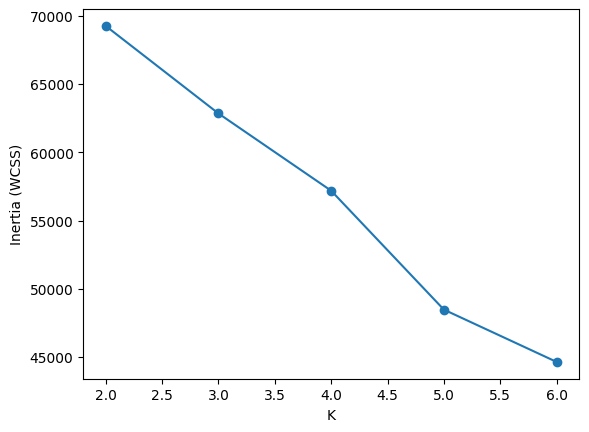

In [35]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = [2, 3, 4, 5, 6]

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_tr_kbest)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia (WCSS)')
plt.show()

Utilizzando K-means, si osserva come il numero di cluster ottimale sia pari a 5 utilizzando l'elbow-method. Cosa ci avrebbe suggerito il silhouette score?

In [36]:
# Definiamo la griglia dei parametri per K (il numero di cluster)
k_values = [2, 3, 4, 5]

best_km_score = -1
best_k_km = None
best_labels_km = None

# Ciclo di ottimizzazione (Grid Search)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_tr_kbest)
    
    # Calcoliamo lo score silhouette per scegliere il K migliore
    score = silhouette_score(X_tr_kbest, labels)
    
    if score > best_km_score:
        best_km_score = score
        best_k_km = k
        best_labels_km = labels

print(f"Miglior numero di cluster K: {best_k_km}")

Miglior numero di cluster K: 3


In questo caso, un altro approccio possibile sarebbe stato quello di forzare k = 2, sapendo già che il numero di etichette desiderate doveva essere 2. 

Superata questa considerazione, adesso passiamo al calcolo dell'accuracy e della purity. Nel caso precedente (più semplice) la matrice di confusione era quadrata e il calcolo di accuracy e purity era abbastanza intuitivo. Adesso invece, immaginiamo di avere una matrice rettangolare 2x3, in cui sulle righe si osservano le etichette reali (il cosiddetto *ground truth*) e sulle colonne quelle predette

In [37]:
cm_km = contingency_matrix(y_tr, best_labels_km)
cm_km

array([[ 295,  254, 2210],
       [1011, 2060, 2819]])

In questo caso il calcolo della accuracy coincide con quello della purity invece si ottiene sempre allo stesso modo.

In [45]:
purity_km = np.sum(np.amax(cm_km, axis=0)) / cm_km.sum()
purity_km 

np.float64(0.6810035842293907)

### Criteri di valutazione esterni

Useremo l'ARI discusso prima!

In [ ]:
# ARI DBSCAN
ari_dbscan = adjusted_rand_score(y_tr, cluster_dbscan)

# ARI KMeans
ari_km = adjusted_rand_score(y_tr, best_labels_km)

print("ARI DBSCAN:", ari_dbscan)
print("ARI KMeans:", ari_km)

Entrambi sono molto bassi, indicando che i cluster identificati non corrispondono bene alle classi di morte.

## Gaussian Mixture



In [40]:
from sklearn.mixture import GaussianMixture
 
gm = GaussianMixture(n_components=2,
                     weights_init=[1/2] * 2,
                     random_state=42)
 
# 3. Addestriamo e generiamo direttamente le etichette per il Punto 4
y_pred_gm = gm.fit_predict(X_tr_kbest)
 
gm.weights_

array([0.50730141, 0.49269859])

In [ ]:
# 1. Genera la matrice di contingenza per il GMM
cm_gm = contingency_matrix(y_tr, y_pred_gm)
print("Matrice di Contingenza GMM:\n", cm_gm)

Matrice di Contingenza GMM:
 [[1919  840]
 [2473 3417]]


In [44]:
# Calcolo della Purity
# Prende il massimo da ogni colonna, li somma e divide per il totale
purity_gm = np.sum(np.amax(cm_gm, axis=0)) / cm_gm.sum()
purity_gm

np.float64(0.6810035842293907)

In [43]:
# Calcolo dell'Accuracy
# Massimo tra la diagonale principale e quella invertita
diag1 = cm_gm[0, 0] + cm_gm[1, 1]
diag2 = cm_gm[0, 1] + cm_gm[1, 0]
accuracy_gm = max(diag1, diag2) / cm_gm.sum()
accuracy_gm

np.float64(0.6169499364088334)

- Se vince il K-Means: Significa che le tue due classi reali nei dati formano dei cluster sferici, compatti e ben separati nello spazio geometrico.

- Se vince il DBSCAN: Significa che le classi hanno forme strane, allungate o non lineari, oppure che c'è molto rumore di fondo che il DBSCAN è riuscito a isolare (coi punti -1), mentre gli altri algoritmi sono stati costretti ad "accorpare" il rumore nei cluster peggiorando la purezza.

- Se vince il GMM: Significa che le classi si sovrappongono parzialmente e hanno forme ellittiche (allungate in certe direzioni della varianza) o dimensioni molto diverse. Il GMM è l'unico dei tre che riesce a modellare l'ovale di una distribuzione grazie alla matrice di covarianza.